## Travelling Salesman Problem

### Solving the TSP via Hopfield Networks

We are going to explore how to solve one of the most famous problems in computer science—the **Travelling Salesman Problem (TSP)**—using the lens of **dynamical systems**.

While TSP is traditionally viewed as a discrete "search" problem, we are going to treat it as a continuous physical process. We will build a "mathematical hill" (an energy landscape) and let a set of differential equations roll toward the bottom.

### 1. The Representation: The Permutation Matrix

To represent a tour of $n$ cities, we use an $n \times n$ matrix of neurons, $V$.

* The **row index $x$** represents the city.
* The **column index $i$** represents the position in the tour.

A neuron $V_{xi}$ represents the hypothesis: *"City $x$ is visited at step $i$."* In a perfect solution, $V$ must be a **permutation matrix** (exactly one '1' in every row and every column).

### 2. The Energy Function $E$

To find the shortest path, we define a scalar **Energy Function**, $E(V)$, which penalizes "illegal" configurations (like visiting two cities at once) and "expensive" configurations (long distances).

$$E = \underbrace{\frac{A}{2} \sum_{x} \sum_{i} \sum_{j \neq i} V_{xi}V_{xj}}_{E_{row}} + \underbrace{\frac{B}{2} \sum_{i} \sum_{x} \sum_{y \neq x} V_{xi}V_{yi}}_{E_{col}} + \underbrace{\frac{C}{2} \left( \sum_{x} \sum_{i} V_{xi} - n \right)^2}_{E_{glob}} + \underbrace{\frac{D}{2} \sum_{x} \sum_{y \neq x} \sum_{i} d_{xy} V_{xi}(V_{y,i+1} + V_{y,i-1})}_{E_{dist}}$$

* **$E_{row}$**: Penalizes multiple stops for the same city.
* **$E_{col}$**: Penalizes multiple cities at the same stop.
* **$E_{glob}$**: Ensures exactly $n$ neurons are active in total.
* **$E_{dist}$**: The objective function. It adds energy proportional to the distance $d_{xy}$ between cities $x$ and $y$ if they are adjacent in the tour ($i \pm 1$).

### 3. Deriving the Gradient Descent

We want our network to evolve such that $E$ decreases over time. We define an internal state $U_{xi}$ for each neuron, which relates to the output $V_{xi}$ via a sigmoid function (to keep $V$ between 0 and 1):


$$V_{xi} = \frac{1}{2} \left( 1 + \tanh\left(\frac{U_{xi}}{u_0}\right) \right)$$

The law of motion is given by the negative gradient of the energy:


$$\frac{dU_{xi}}{dt} = -\frac{\partial E}{\partial V_{xi}}$$

Let's derive the partial derivatives for each term:

1. **$\frac{\partial E_{row}}{\partial V_{xi}}$**: Only terms containing $V_{xi}$ remain. Since we sum over $j \neq i$, we get: $A \sum_{j \neq i} V_{xj}$.
2. **$\frac{\partial E_{col}}{\partial V_{xi}}$**: Similarly: $B \sum_{y \neq x} V_{yi}$.
3. **$\frac{\partial E_{glob}}{\partial V_{xi}}$**: Using the chain rule on the square: $C \left( \sum_{x} \sum_{i} V_{xi} - n \right)$.
4. **$\frac{\partial E_{dist}}{\partial V_{xi}}$**: $V_{xi}$ is multiplied by its neighbors in the tour sequence: $D \sum_{y \neq x} d_{xy} (V_{y,i+1} + V_{y,i-1})$.

**The Complete Differential Equation:**


$$\frac{dU_{xi}}{dt} = -U_{xi} - \left[ A \sum_{j \neq i} V_{xj} + B \sum_{y \neq x} V_{yi} + C \left( \sum \sum V - n \right) + D \sum_{y \neq x} d_{xy}(V_{y,i+1} + V_{y,i-1}) \right]$$

### 4. Discretization: The Euler Method

Computers cannot solve continuous differential equations directly. We must discretize time into small steps $\Delta t$. Using the **Euler Method**, we approximate the next state $U(t + \Delta t)$ based on the current slope:

$$U_{xi}(t + \Delta t) \approx U_{xi}(t) + \Delta t \cdot \frac{dU_{xi}}{dt}$$

By iterating this millions of times, the system "flows" toward a local minimum of $E$.

### 5. Python Implementation

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# --- Generate cities
def generate_cities(n):
    return np.random.rand(n, 2)

In [3]:
# --- Distancies
def get_dist_matrix(coords):
    return np.sqrt(np.sum((coords[:, None] - coords[None, :])**2, axis=2))

In [4]:
def solve_tsp_hopfield(coords, iterations=2000, dt=0.001):
    # 1. Distances
    n_cities=len(coords)
    dist = get_dist_matrix(coords)
    
    # 2. Hyperparameters
    A, B, C, D = 500, 500, 200, 300
    u0 = 0.02 # Gain parameter for sigmoid
    
    # 3. Initialization
    U = np.random.uniform(-0.01, 0.01, (n_cities, n_cities))
    
    # 4. Simulation (Euler Method)
    for _ in range(iterations):
        V = 0.5 * (1 + np.tanh(U / u0))
        
        dU = np.zeros((n_cities, n_cities))
        for x in range(n_cities):
            for i in range(n_cities):
                # Row constraint: city x only once
                term_A = A * (np.sum(V[x, :]) - 1)
                # Column constraint: stop i only once
                term_B = B * (np.sum(V[:, i]) - 1)
                # Global constraint: exactly n active
                term_C = C * (np.sum(V) - n_cities)
                # Distance objective
                prev, nxt = (i - 1) % n_cities, (i + 1) % n_cities
                term_D = D * np.sum(dist[x, :] * (V[:, prev] + V[:, nxt]))
                
                dU[x, i] = -U[x, i] - (term_A + term_B + term_C + term_D)
        
        U += dt * dU
        
    # 5. Extraction
    final_V = 0.5 * (1 + np.tanh(U / u0))
    tour = [np.argmax(final_V[:, i]) for i in range(n_cities)]
    
    return tour, final_V

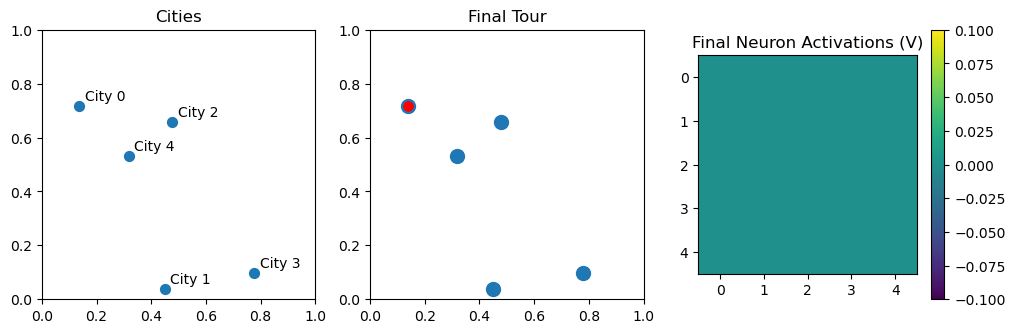

In [5]:
# --- Execution & Visualization ---
N = 5
coords = generate_cities(N)
tour, final_V = solve_tsp_hopfield(coords)

# Visualization
plt.figure(figsize=(12, 3.5))

# Plot Cities
plt.subplot(1, 3, 1)
plt.xlim(0, 1) 
plt.ylim(0, 1) 
plt.scatter(coords[:, 0], coords[:, 1], s=50);
for i, (x, y) in enumerate(coords):
    plt.text(x + 0.02, y + 0.02, f"City {i}")
plt.title("Cities")

# Plot Tour
plt.subplot(1, 3, 2)
plt.xlim(0, 1) 
plt.ylim(0, 1) 
plot_path = coords[tour + [tour[0]]]
plt.scatter(coords[:, 0], coords[:, 1], s=100);
plt.plot(plot_path[:, 0], plot_path[:, 1], 'ro-')
plt.title("Final Tour")
    
# Plot Neuron Matrix
plt.subplot(1, 3, 3)
plt.imshow(final_V, cmap='viridis')
plt.title("Final Neuron Activations (V)")
plt.colorbar()
    
plt.show()

### Important Caution

While mathematically elegant, the Hopfield network is highly sensitive to the constants $A, B, C, D$. If $D$ is too large, the network favors short paths but creates illegal tours (skipping cities). If $A$ is too large, it creates legal tours that are very long. Finding the "Goldilocks zone" is the real challenge!